<a href="https://colab.research.google.com/github/depresssed-kid/leaf_segmentation/blob/main/tuned_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U segmentation-models-pytorch
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 49.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import albumentations as A
import segmentation_models_pytorch as smp


from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
data_path = '/content/drive/MyDrive/kaggle/leaf_seg/data/data'
data_path_im = data_path + '/images'

len_im = len([name for name in os.listdir(data_path_im) if os.path.isfile(os.path.join(data_path_im,name))])
print(len_im)

588


In [ ]:
augmentations = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ])

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-4-977ca96a671c>:6: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


In [ ]:
def augment_data(image, mask, augmentations, num_augmented_copies=3):
    augmented_data = []
    for _ in range(num_augmented_copies):
        augmented = augmentations(image=image, mask=mask)
        augmented_image = augmented['image']
        augmented_mask = augmented['mask']
        augmented_data.append((augmented_image, augmented_mask))
    return augmented_data

In [ ]:
aug_data = False
masks = []
images = []

for num_img in range(len_im):
  number_str = str(num_img)
  num_zeros = 5 - len(number_str)
  cur_num = "0"*num_zeros +number_str

  mask = cv2.imread(data_path + "/masks/"  + cur_num+'.png', cv2.IMREAD_COLOR)
  image = cv2.imread(data_path + "/images/"  + cur_num+'.jpg', cv2.IMREAD_COLOR)
  image = cv2.resize(image,(256,256))[:, :, ::-1]
  mask = cv2.resize(mask,(256,256))[:, :, ::-1]
  mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  image = np.asarray(image)
  mask = np.asarray(mask)
  mask = np.where(mask != 0,1.,0.)
  masks.append(mask)
  images.append(image)
  if aug_data:
    aug_data = augment_data(image, mask,augmentations)
    for (image_aug, mask_aug) in aug_data:
      images.append(image_aug)
      masks.append(mask_aug)

masks = np.asarray(masks)
images = np.asarray(images)
print(f'labels shape: {masks.shape}')
print(f'images shape: {images.shape}')

labels shape: (588, 256, 256)
images shape: (588, 256, 256, 3)


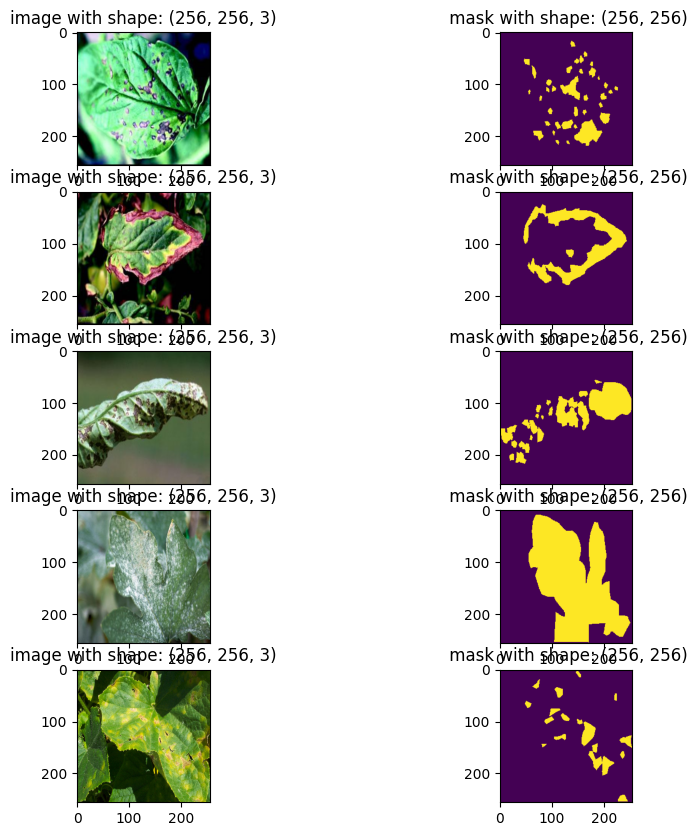

In [ ]:
fig, axs = plt.subplots(5, 2, figsize=(10, 10))

for i in range(5):
  axs[i,0].set_title(f'image with shape: {images[i].shape}')
  axs[i,0].imshow(images[i])

  axs[i,1].set_title(f' mask with shape: {masks[i].shape}')
  axs[i,1].imshow(masks[i])
plt.show()

In [ ]:
class DataSet():
  def __init__(self, images, masks, transform = None, mask_transforms = None):
    """
    Inputs:
      images - array of images
      masks - array of true masks for images
      transform - torchvision.transforms object for image preprocessing
    """
    self.image = images
    self.mask = masks
    self.transform = transform
    self.mask_transforms = mask_transforms

  def __getitem__(self, index):
      image = self.image[index]
      mask = self.mask[index]

      if self.transform:
          image = self.transform(image)
      if self.mask_transforms:
          mask = self.mask_transforms(mask)

      return image, mask


  def __len__(self):
    return len(self.image)

In [ ]:
X_train, X_res, y_train, y_res = train_test_split(images, masks, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_res, y_res, test_size=0.1, random_state=42)


DATA_MEANS = (X_train / 255.0).mean(axis=(0, 1, 2))
DATA_STD = (X_train / 255.0).std(axis=(0, 1, 2))

print(f'train size: {len(X_train)} test size: {len(X_test)} val size: {len(X_val)} ')

train size: 470 test size: 12 val size: 106 


In [ ]:
resize = (256,256)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATA_MEANS, std=DATA_STD)
])
transform_mask = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])


In [ ]:
train_dataset = DataSet(X_train,
                        y_train,
                        transform,
                        transform_mask
                        )

val_dataset = DataSet(X_val,
                        y_val,
                        transform,
                        transform_mask
                      )
test_dataset = DataSet(X_test,
                        y_test,
                        transform,
                        transform_mask
                      )

In [ ]:
BATCH_SIZE = 8
patience = 10
num_epochs = 25
learning_rate = 0.0003
pos_weight = torch.tensor([masks_all/masks_sum])

In [ ]:
NUM_WORKERS = os.cpu_count()


train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS)

val_dataloader = DataLoader(dataset = val_dataset,
                            batch_size = 1,
                            shuffle = False,
                            num_workers = NUM_WORKERS)

test_dataloader = DataLoader(dataset = test_dataset,
                            batch_size = 1,
                            shuffle = False,
                            num_workers = NUM_WORKERS)

In [ ]:
len(train_dataloader)

59

In [ ]:
def check_score(loader, model,loss, device="cuda"):
    running_loss=0
    iou=0
    dice_score  = 0
    with torch.no_grad():
        for img, mask in tqdm(loader):
            img   = img.to(device)
            mask  = mask.to(device)
            preds = model(img)

            running_loss += loss(preds,mask)
            iou += iou_score(preds, mask)
            preds = (preds > 0.5).float()
            dice_score += (2 * (preds * mask).sum()) / (
                (preds + mask).sum() + 1e-7
            )
        iou = iou/len(loader)
        loss = running_loss/len(loader)
        final_dice = dice_score/len(loader)
    print(
        f"Got iou: {iou}, dice: {final_dice} and loss: {loss}"
    )
    return iou, loss

In [ ]:
def train(model,criterion, optimizer, scheduler, num_epochs=100,patience=7,name = 'best_model.pth' ):
  best_loss = float('inf')

  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for (images, labels) in tqdm(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    model.eval()
    iou, val_loss = check_score(val_dataloader, model, criterion, device=device)
    scheduler.step(val_loss)
    if val_loss < best_loss:
        torch.save(model.state_dict(), name)
        best_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= patience:
        break

In [ ]:
unet= smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
unet= unet.to(device)

In [ ]:
criterion = smp.losses.DiceLoss(mode= 'binary')
optimizer = optim.AdamW(unet.parameters(),
                        lr=learning_rate,
                        betas=(0.9, 0.999), weight_decay=0.05,)
scheduler = ReduceLROnPlateau(optimizer, 'min',patience=7)

In [ ]:
train(unet, criterion, optimizer, scheduler, name = 'unet.pth')

100%|██████████| 106/106 [00:01<00:00, 64.82it/s]


Got iou: 0.6150380373001099, dice: 0.7394967675209045 and loss: 0.27975717186927795


100%|██████████| 106/106 [00:01<00:00, 63.52it/s]


Got iou: 0.5604612827301025, dice: 0.7007692456245422 and loss: 0.3140820562839508


100%|██████████| 106/106 [00:02<00:00, 50.05it/s]


...

Got iou: 0.6806071996688843, dice: 0.7869008779525757 and loss: 0.21398630738258362


100%|██████████| 106/106 [00:01<00:00, 63.46it/s]


Got iou: 0.6842647790908813, dice: 0.7887381911277771 and loss: 0.211910218000412


100%|██████████| 106/106 [00:02<00:00, 47.65it/s]

Got iou: 0.6817449331283569, dice: 0.7879793643951416 and loss: 0.212347611784935


In [ ]:
deeplabv3_plus= smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
criterion = smp.losses.DiceLoss(mode= 'binary')
optimizer = optim.AdamW(deeplabv3_plus.parameters(),
                        lr=learning_rate,
                        betas=(0.9, 0.999), weight_decay=0.05,)
scheduler = ReduceLROnPlateau(optimizer, 'min',patience=7)

deeplabv3_plus= deeplabv3_plus.to(device)
train(deeplabv3_plus, criterion, optimizer, scheduler, name = 'deeplabv3_plus.pth')

100%|██████████| 106/106 [00:01<00:00, 63.68it/s]


Got iou: 0.40146198868751526, dice: 0.53128981590271 and loss: 0.5103909373283386


100%|██████████| 106/106 [00:01<00:00, 62.08it/s]


Got iou: 0.544837474822998, dice: 0.6831119656562805 and loss: 0.3878927528858185


100%|██████████| 106/106 [00:01<00:00, 55.46it/s]


...

Got iou: 0.638167679309845, dice: 0.749819278717041 and loss: 0.2537657618522644


100%|██████████| 106/106 [00:02<00:00, 43.99it/s]


Got iou: 0.6497374773025513, dice: 0.761162519454956 and loss: 0.24286100268363953


100%|██████████| 106/106 [00:01<00:00, 64.41it/s]

Got iou: 0.6380887627601624, dice: 0.7577003240585327 and loss: 0.24818295240402222


In [ ]:
segformer = smp.Segformer(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
criterion = smp.losses.DiceLoss(mode= 'binary')
optimizer = optim.AdamW(segformer.parameters(),
                        lr=learning_rate,
                        betas=(0.9, 0.999), weight_decay=0.05,)
scheduler = ReduceLROnPlateau(optimizer, 'min',patience=7)

segformer= segformer.to(device)
train(segformer, criterion, optimizer, scheduler, name = 'segformer.pth')

100%|██████████| 106/106 [00:02<00:00, 47.37it/s]


Got iou: 0.5368606448173523, dice: 0.6624277234077454 and loss: 0.3715788424015045


100%|██████████| 106/106 [00:01<00:00, 60.42it/s]


Got iou: 0.5883896350860596, dice: 0.7123957276344299 and loss: 0.31029680371284485


100%|██████████| 106/106 [00:01<00:00, 59.53it/s]


...

Got iou: 0.6455878615379333, dice: 0.7561848759651184 and loss: 0.2477322667837143


100%|██████████| 106/106 [00:02<00:00, 44.68it/s]


Got iou: 0.6414774060249329, dice: 0.7541311979293823 and loss: 0.2463957518339157


100%|██████████| 106/106 [00:01<00:00, 61.27it/s]

Got iou: 0.6422197818756104, dice: 0.7520222067832947 and loss: 0.24672773480415344


In [ ]:
#inference
unet.load_state_dict(torch.load('unet.pth'))
segformer.load_state_dict(torch.load('segformer.pth'))
deeplabv3_plus.load_state_dict(torch.load('deeplabv3_plus.pth'))

print('unet:', end=' ')
check_score(test_dataloader,unet,criterion)
print('segformer:', end=' ')
check_score(test_dataloader,segformer,criterion)
print('deeplabv3_plus:', end=' ')
check_score(test_dataloader,deeplabv3_plus,criterion)

unet: 

100%|██████████| 12/12 [00:00<00:00, 18.93it/s]


Got iou: 0.604328989982605, dice: 0.7315539121627808 and loss: 0.2709885239601135
segformer: 

100%|██████████| 12/12 [00:00<00:00, 19.53it/s]


Got iou: 0.6845154762268066, dice: 0.7970799803733826 and loss: 0.21668532490730286
deeplabv3_plus: 

100%|██████████| 12/12 [00:00<00:00, 20.67it/s]

Got iou: 0.6935898065567017, dice: 0.8045210838317871 and loss: 0.20489197969436646


(tensor(0.6936, device='cuda:0'), tensor(0.2049, device='cuda:0'))

несмотря на меньшее кол-во параметров, segformer почти так же как deeplabV3+

In [ ]:
def after_processing(outputs):
  outputs = torch.sigmoid(outputs)
  outputs = (outputs > 0.5).float()
  outputs = outputs.to('cpu').detach().numpy()
  return outputs

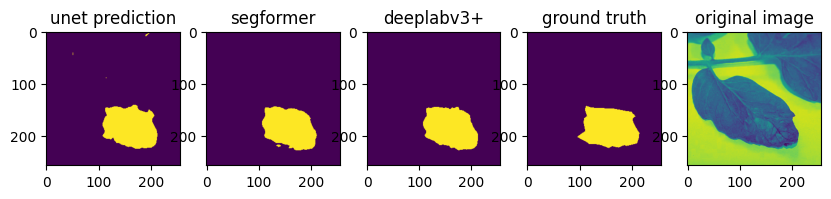

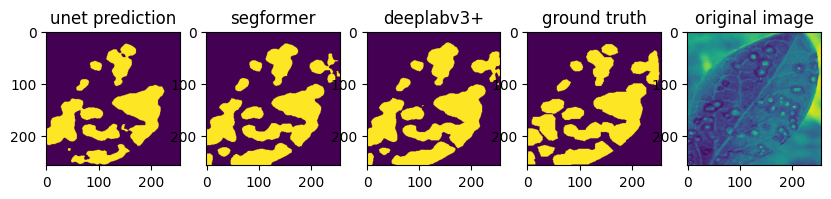

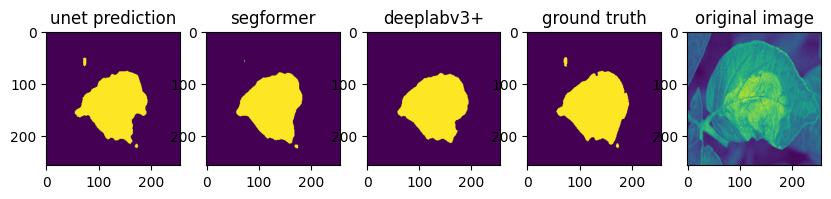

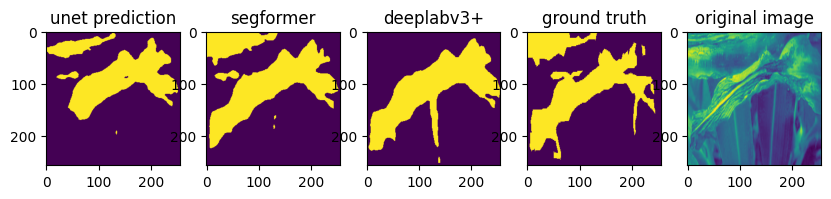

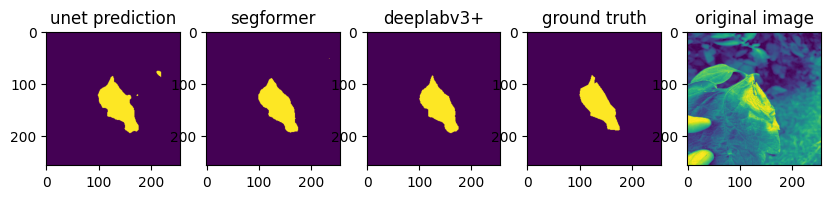

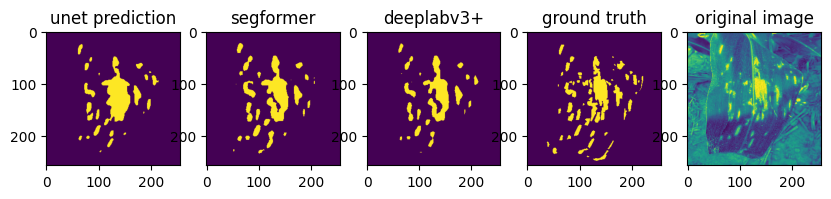

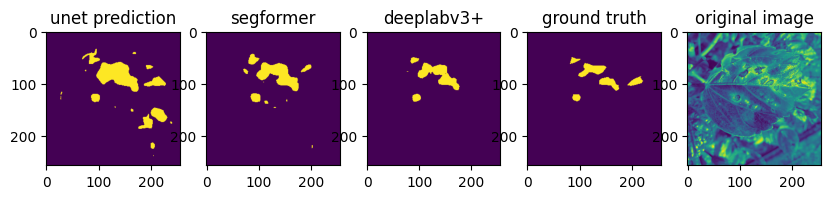

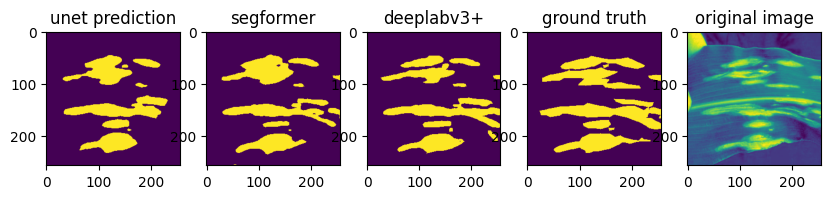

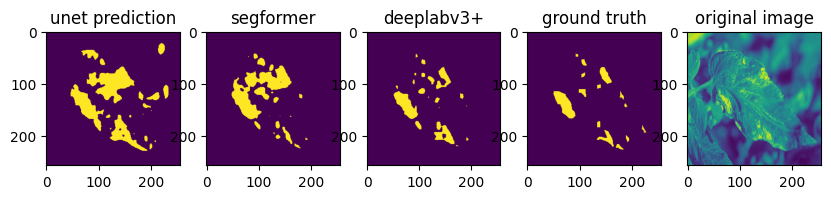

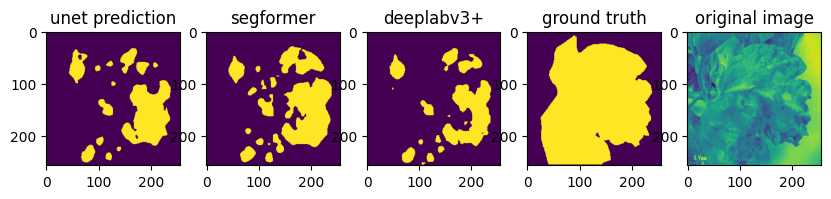

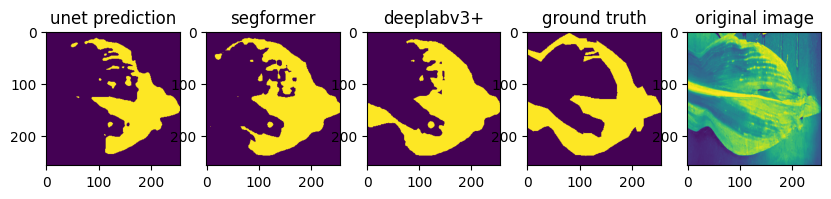

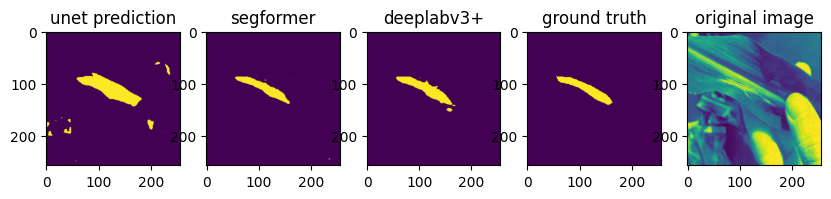

In [ ]:
for (images, masks) in test_dataloader:
  images = images.to(device)
  unet_outputs = after_processing(unet(images))
  segformer_outputs = after_processing(segformer(images))
  deeplabv3_plus_outputs = after_processing(deeplabv3_plus(images))

  images = images.to('cpu').detach().numpy()
  fig, axs = plt.subplots(1, 5, figsize=(10, 10))


  axs[0].imshow(unet_outputs[0][0])
  axs[0].set_title('unet prediction')

  axs[1].imshow(segformer_outputs[0][0])
  axs[1].set_title('segformer')

  axs[2].imshow(deeplabv3_plus_outputs[0][0])
  axs[2].set_title('deeplabv3+')

  axs[3].imshow(masks[0][0])
  axs[3].set_title('ground truth')

  axs[4].imshow(images[0][0])
  axs[4].set_title('original image')
  plt.show()